In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Settings for nicer plots
plt.style.use("seaborn-v0_8")

# ==============================
# 1) Load weekly processed data and focus beers
# ==============================

weekly_df = pd.read_csv("data/processed/weekly_beer_data.csv", parse_dates=["week"])

# Normalise beer names so aliases are treated as the same beer
BEER_ALIAS_MAP = {
    "Hoop US Lager": "Hoop Lager",
    "Hoop Lager": "Hoop Lager",
    "Hoop Kaper North East IPA": "Hoop Kaper Tropical IPA",
    "Hoop Kaper Tropical IPA": "Hoop Kaper Tropical IPA",
    "Hoop Bleke Nelis": "Hoop Bleke Nelis",
}
weekly_df["beer"] = weekly_df["beer"].replace(BEER_ALIAS_MAP)

CORE_BEERS = [
    "Hoop Bleke Nelis",
    "Hoop Lager",
    "Hoop Kaper Tropical IPA",
]

core_weekly = weekly_df[weekly_df["beer"].isin(CORE_BEERS)].copy()

print("Rows for core beers:", len(core_weekly))

Rows for core beers: 3978


In [3]:
# ==============================
# 2) Aggregate liters per week per beer (all containers)
# ==============================

agg_weekly = (
    core_weekly
    .groupby(["week", "beer"], as_index=False)["liters"]
    .sum()
)

# Also create a monthly view (optional)
agg_weekly["month_start"] = agg_weekly["week"].dt.to_period("M").dt.to_timestamp()
agg_monthly = (
    agg_weekly
    .groupby(["month_start", "beer"], as_index=False)["liters"]
    .sum()
)

agg_weekly.head()

,week,beer,liters,month_start
0,2021-11-22,Hoop Bleke Nelis,198.00,2021-11-01
1,2021-11-22,Hoop Kaper Tropical IPA,9.90,2021-11-01
2,2021-11-22,Hoop Lager,0.00,2021-11-01
3,2021-11-29,Hoop Bleke Nelis,355.15,2021-11-01
4,2021-11-29,Hoop Kaper Tropical IPA,53.46,2021-11-01


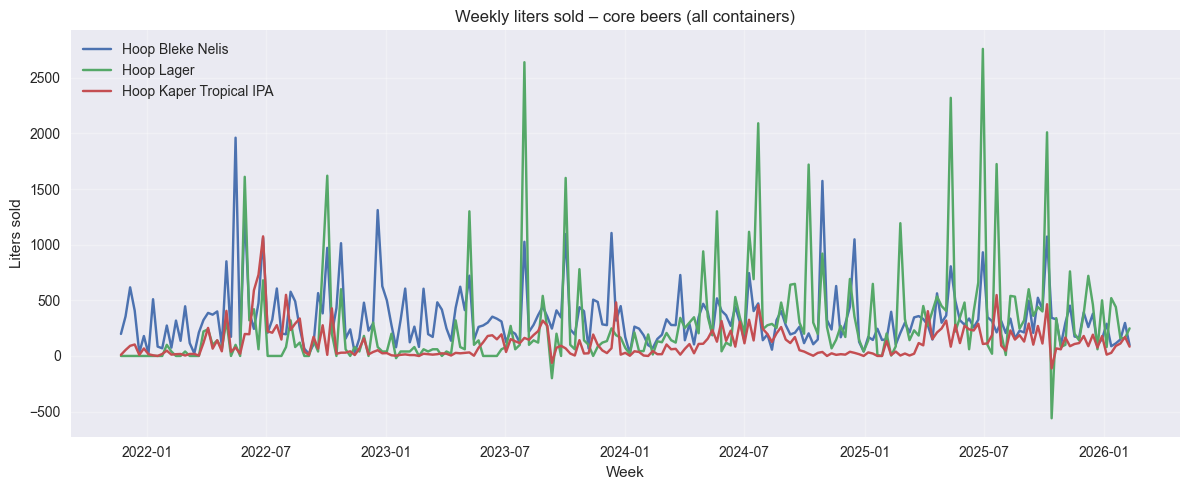

In [4]:
# ==============================
# 3) Plot weekly sales history for each core beer
# ==============================

fig, ax = plt.subplots(figsize=(12, 5))

for beer in CORE_BEERS:
    df_b = agg_weekly[agg_weekly["beer"] == beer]
    ax.plot(df_b["week"], df_b["liters"], label=beer)

ax.set_title("Weekly liters sold – core beers (all containers)")
ax.set_xlabel("Week")
ax.set_ylabel("Liters sold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

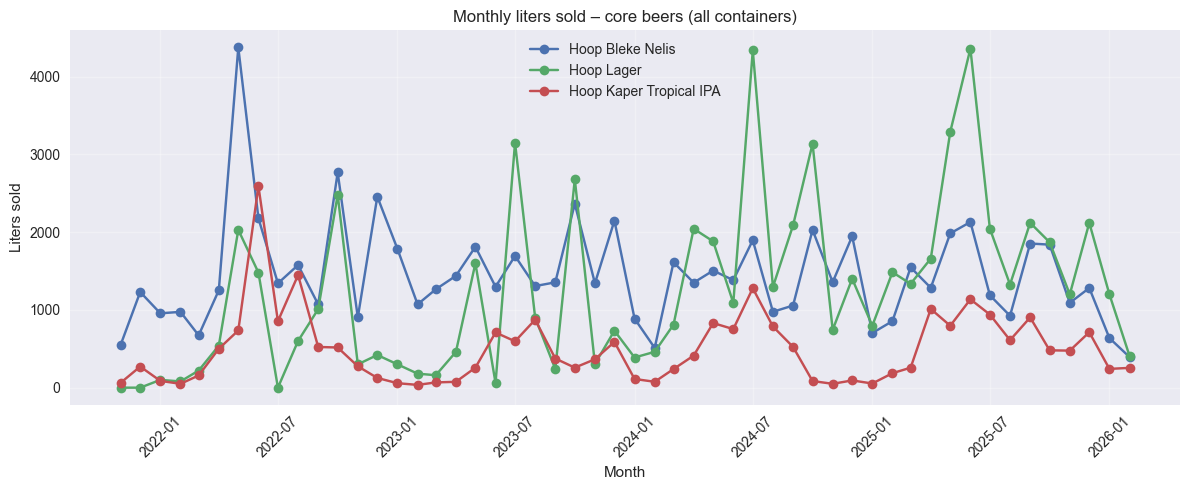

In [5]:
# ==============================
# 4) Plot monthly sales history for each core beer (smoother)
# ==============================

fig, ax = plt.subplots(figsize=(12, 5))

for beer in CORE_BEERS:
    df_b = agg_monthly[agg_monthly["beer"] == beer]
    ax.plot(df_b["month_start"], df_b["liters"], marker="o", label=beer)

ax.set_title("Monthly liters sold – core beers (all containers)")
ax.set_xlabel("Month")
ax.set_ylabel("Liters sold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Last month in data: 2026-02-01
Window start: 2025-02-01


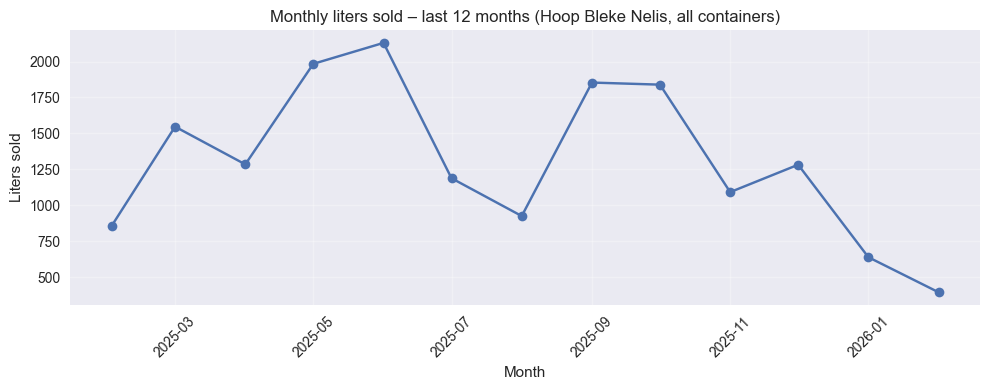

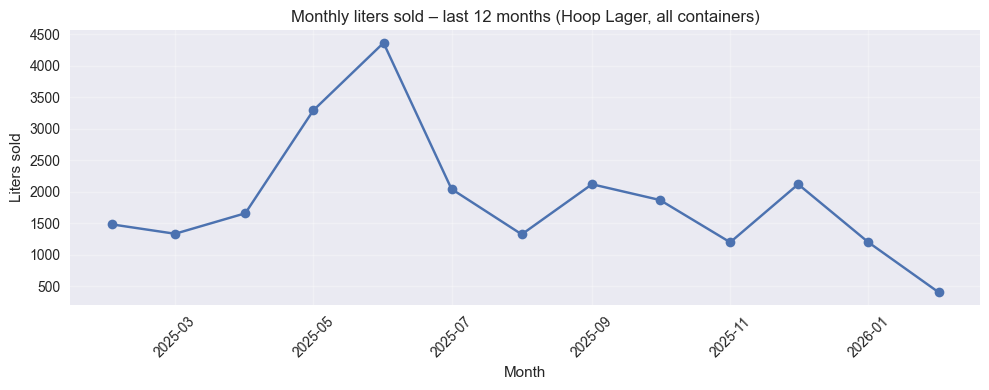

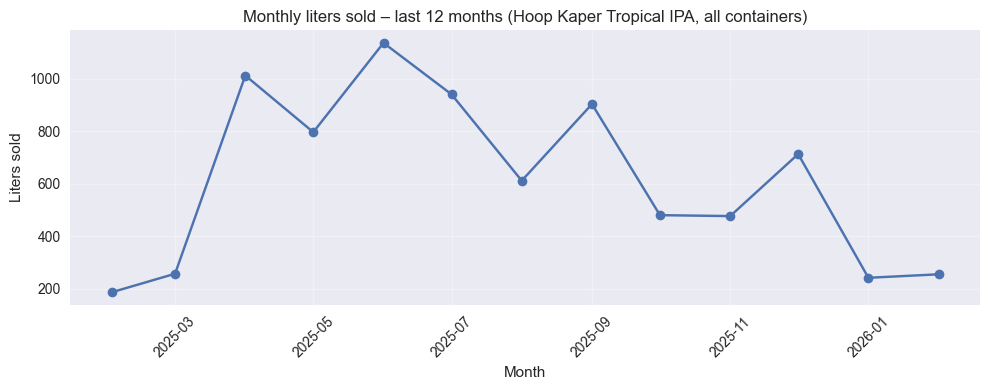

In [6]:
# ==============================
# 5) Per-beer monthly plots for LAST 12 MONTHS
# ==============================

# Determine last month in the data and a 12-month window
last_month = agg_monthly["month_start"].max()
window_start = last_month - pd.DateOffset(years=1)

last12 = agg_monthly[agg_monthly["month_start"] >= window_start].copy()
print("Last month in data:", last_month.date())
print("Window start:", window_start.date())

for beer in CORE_BEERS:
    df_b = last12[last12["beer"] == beer].sort_values("month_start")
    if df_b.empty:
        print(f"No data for {beer} in last 12 months.")
        continue

    plt.figure(figsize=(10, 4))
    plt.plot(df_b["month_start"], df_b["liters"], marker="o")
    plt.title(f"Monthly liters sold – last 12 months ({beer}, all containers)")
    plt.xlabel("Month")
    plt.ylabel("Liters sold")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

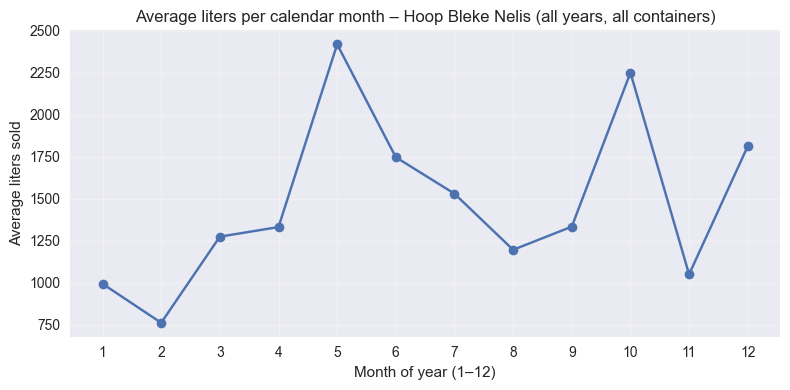

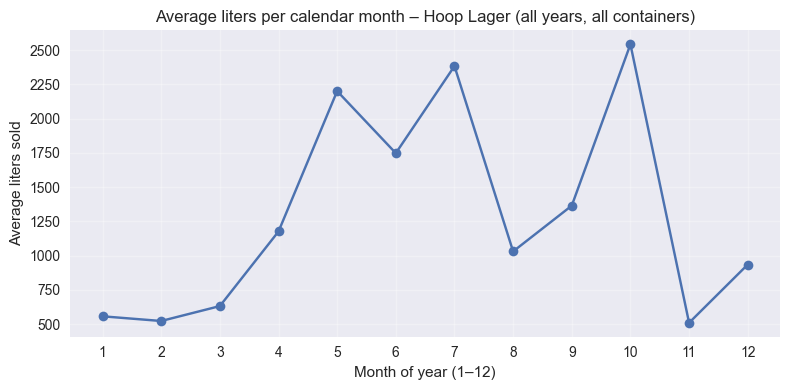

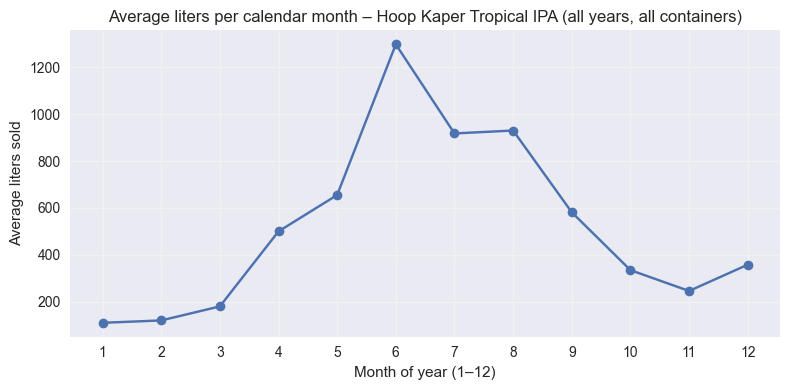

In [7]:
# ==============================
# 6) Seasonality: average liters per calendar month for each core beer
# ==============================

# Add month number for grouping
seasonal = agg_monthly.copy()
seasonal["month"] = seasonal["month_start"].dt.month

monthly_avg = (
    seasonal
    .groupby(["month", "beer"], as_index=False)["liters"]
    .mean()
)

for beer in CORE_BEERS:
    df_b = monthly_avg[monthly_avg["beer"] == beer].sort_values("month")
    if df_b.empty:
        print(f"No data for {beer} to compute monthly averages.")
        continue

    plt.figure(figsize=(8, 4))
    plt.plot(df_b["month"], df_b["liters"], marker="o")
    plt.title(f"Average liters per calendar month – {beer} (all years, all containers)")
    plt.xlabel("Month of year (1–12)")
    plt.ylabel("Average liters sold")
    plt.xticks(range(1, 13))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()